In [10]:
import datetime as dt
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools


In [11]:
#"Regex to extract datetime, sender and message of a line"
def extract_msg(line):
    date = []
    time = []
    msg = []
    sender_name = []
    datetime_pat  = "(\d+/\d+/\d+) (\d+:\d+) - (.*?): (.*)"  
    msgdata = re.findall(datetime_pat, line)
    date,time,sender_name, msg = msgdata[0][0],msgdata[0][1],msgdata[0][2],msgdata[0][3]

        
    return date, time, sender_name, msg



In [12]:
#Using extract message create a df of messages
def creartab(filedir):
    f = open('%s'%filedir, 'r', encoding='utf-8') # chat.txt arquivo
    content = f.readlines()
    content = [x.strip() for x in content] 
    conv0 = pd.DataFrame(columns=['date',"time",'sender','message'])
    erros = []
    for i in range(len(content)):
        try :
            date,time,sender, msg  = extract_msg(content[i]);
            temp_df = pd.Series({'date':date ,"time": time,'sender':sender,'message':msg}) 
            conv0 = conv0.append(temp_df, ignore_index=True)
        except IndexError:
            #print(i)
            pass
    return conv0
    f.close()
#creartab("chat.txt")

In [13]:
#filldates fills dates in between in period starting in begindate and ending in enddate
def filldates(conv0, begindate, enddate, periodo):
    totaldedias = pd.date_range(start=begindate, end=enddate, periods=periodo).to_pydatetime().tolist()
    diastot = []
    for i in totaldedias:
        diastot.append(i.strftime("%d/%-m/%y")) #Lista dos totais

    semduplicado = conv0.drop_duplicates("date")#Tirando duplicados
    fechas = semduplicado["date"].tolist() #Lista dos usados

    for dia in diastot: #Colocando todas as fechas no array
        if dia not in fechas:
            fechas.append(dia)
    return fechas

In [14]:
#pessoasstrdic = { " an" : "Andres" , "jf" :"Jonfer"} #pessoasstrdic has to have to be this way
#
def msgcounterforn(conv0, fechas, pessoasstrdic):    
    msgcadaum = pd.DataFrame(columns=['date'] + list(pessoasstrdic.keys())) #msgs roberto e da milena
    convpordate = conv0.groupby("date")
    savedname = pessoasstrdic.copy()
    l = 0
    for i in fechas:        
        l +=1 
        for autostr in list(pessoasstrdic.keys()):
            nametosearch = savedname[autostr] #saving name to search #TAAAAQUYI O PROBLEMA
            #print(savedname)
            #print(nametosearch)
            try:
                pessoasstrdic[autostr] = len(convpordate.get_group(i).groupby("sender").get_group(nametosearch).index) #Separa msg por dia(i) depois por autor e agarra especificos e cuenta
            except KeyError as e:
                pessoasstrdic[autostr] = 0
        dictoadd = {"date" : i}
        dictoadd.update(pessoasstrdic)
        temp_df = pd.Series(dictoadd) 
        msgcadaum = msgcadaum.append(temp_df, ignore_index=True)
    msgcadaum['date'] =pd.to_datetime(msgcadaum.date, format='%d/%m/%y')
    msgcadaum = msgcadaum.sort_values(by='date')
    msgcadaum["date"] = msgcadaum["date"].apply(lambda x: x.strftime('%d/%m/%y')) 
    
    return msgcadaum
        


In [15]:
def plotternummsgpordia(msgcadaum,pessoasstrdic):
    fig, ax1 = plt.subplots(figsize=(30,20))
    ax1.set_ylabel(r"Número de mensajes enviados")
    ax1.set_xlabel(r"Dia")
    ax1.xaxis.set_major_locator(plt.MaxNLocator(130))
    plt.xticks(rotation=45)

    
    for pessoa in list(pessoasstrdic.keys()):
        plt.plot(msgcadaum["date"], msgcadaum[pessoa], label = pessoasstrdic[pessoa])
    

    ax1.legend(loc='best')
    fig.savefig("amiguinhos1.pdf", bbox_inches='tight')
    

In [16]:
def plottotal(msgcadaum, pessoasstrdic):    
    fig, ax1 = plt.subplots(figsize=(8,8))

    objects = list(pessoasstrdic.values())
    y_pos = np.arange(len(objects))
    performance = []
    for i in list(pessoasstrdic.keys()):
            performance.append( msgcadaum[i].sum() )

    plt.bar(y_pos, performance, align='center', alpha=0.5)
    plt.xticks(y_pos, objects)
    plt.ylabel('Mensajes totales')
    plt.title("Mensajes totales enviados por cada uno")

    plt.show()
    fig.savefig("amiguinhostotales.pdf", bbox_inches='tight')

In [17]:
def programatotal(filedir, Autores, begindate, enddate, period):
    conv1copia = creartab(filedir) 
    copiadeAutores = Autores.copy()
    arraydefechas = filldates(conv1copia,begindate, enddate, period)
    tabela = msgcounterforn(conv1copia, arraydefechas, Autores)
    plotternummsgpordia(tabela, copiadeAutores)
    plottotal(tabela, copiadeAutores)

In [ ]:
Autores = {'sb':"Sebastian" ,'ro': "Roberto", "alArg": "AlvaroArg", "alV": "Alvaro(Valencia)" , "an": "Andrés Colombia", "jf" : "Jonfer"}
#programatotal("chat", Autores, '2018-09-18', '2020-02-7', 400 )

In [ ]:
Autores = {'mi':"Milena" ,'ro': "Roberto"}
#programatotal("chat/chatMI.txt" , Autores, '2018-06-11', '2020-01-24', 400 )

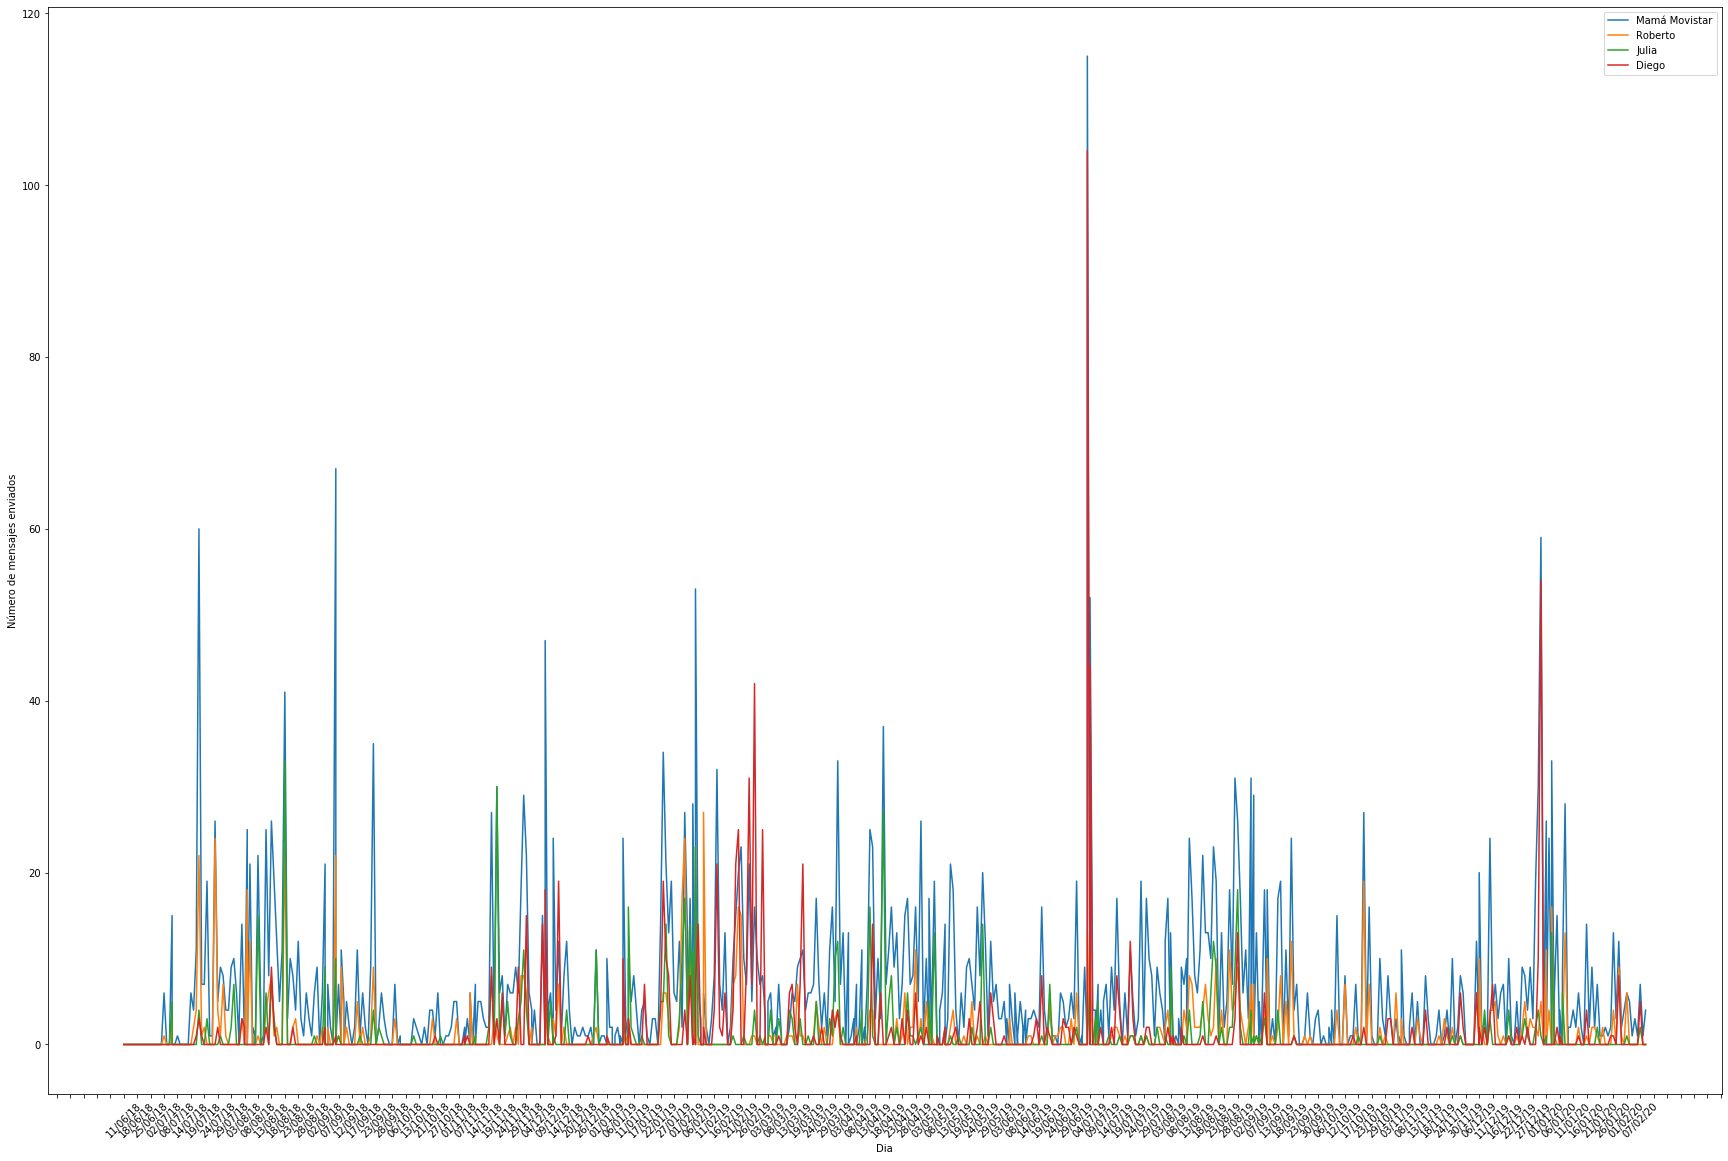

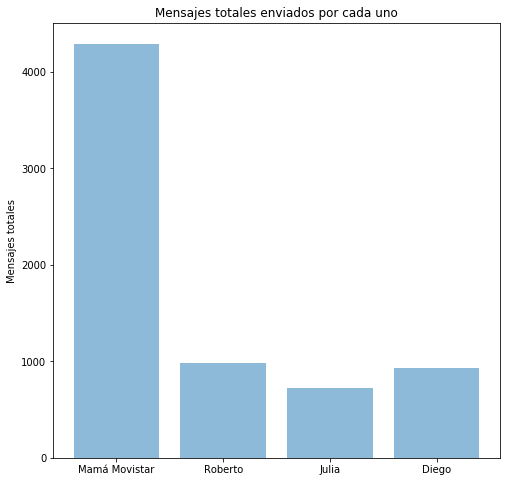

In [18]:
Autores = {'mama':"Mamá Movistar" ,'ro': "Roberto", "ju": "Julia", "die": "Diego"}
programatotal("ChatMam.txt" , Autores, '2018-06-11', '2020-01-24', 400 )